# Outlier Analysis (topic = −1) — Combined

Documents assigned to topic **−1** by HDBSCAN are *noise* — they did not fall
inside any dense cluster. This notebook profiles those outliers across **both**
corpora (iGEM teams and SynBio papers) to understand **why** the outlier rate is
high and whether any of them could reasonably be reassigned.

Run the teams and papers topic-model notebooks first so the
`assets/topic_models/*_doc_topics.txt` files exist.

In [1]:
# ── Make the shared aux/ package importable ───────────────────────────────────
# These notebooks live one level below 02-topic_model/, where the aux/ package
# resides; add that folder to the import path.
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

## 1. Load data

In [2]:
import pandas as pd
from IPython.display import display

from aux.paths import SEED, set_seed
from aux.orphans import (
    load_outlier_inputs, outlier_summary, plot_outlier_rate_by_year,
    plot_text_length, language_outlier_table, nearest_centroid_analysis,
    citation_profile, concept_overlap, sample_outlier_docs,
    sample_outlier_table, save_orphans, build_summary,
)

set_seed()

papers, papers_emb, papers_topics = load_outlier_inputs(
    raw_file="synbio_openalex.txt",
    embeddings_file="papers_embeddings.npy",
    doc_topics_file="papers_doc_topics.txt",
    id_col="id",
)
teams, teams_emb, teams_topics = load_outlier_inputs(
    raw_file="igem.txt",
    embeddings_file="teams_embeddings.npy",
    doc_topics_file="teams_doc_topics.txt",
    id_col="UT",
)
print(f"Papers: {len(papers):,}  |  Teams: {len(teams):,}")

Papers: 19,017  |  Teams: 4,707


## 2. Outlier overview

In [3]:
outlier_summary(papers, "Papers", "publication_year")
outlier_summary(teams, "Teams", "PY")

── Papers ────────────────────────────────────────────
  Total docs   :   19,017
  Assigned     :   12,796  (67.3%)
  Outliers (−1):    6,221  (32.7%)
  Year range   : 2004 – 2025

── Teams ─────────────────────────────────────────────
  Total docs   :    4,707
  Assigned     :    4,707  (100.0%)
  Outliers (−1):        0  (0.0%)
  Year range   : 2004 – 2025



## 3. Outlier rate by year

If outliers concentrate in certain years the data may simply be sparse or the
vocabulary may differ in those periods.

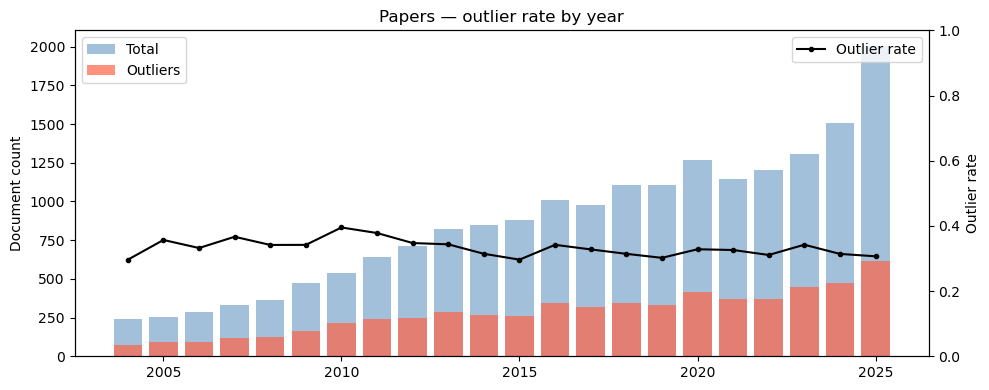

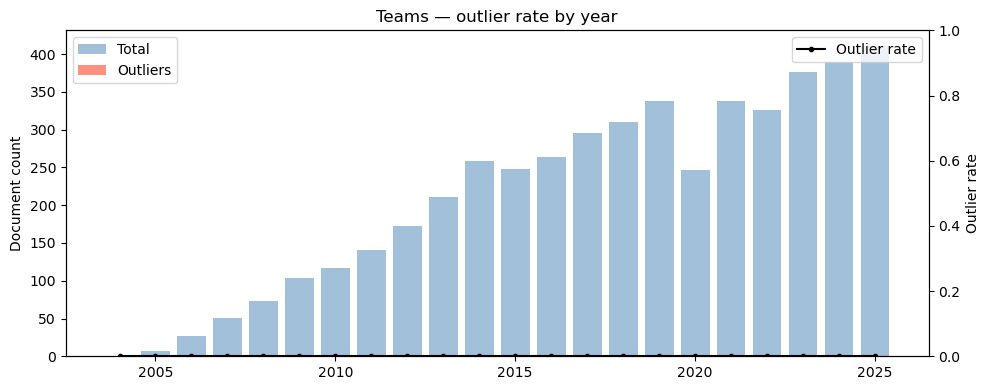

In [4]:
plot_outlier_rate_by_year(papers, "publication_year", "Papers — outlier rate by year")
plot_outlier_rate_by_year(teams, "PY", "Teams — outlier rate by year")

## 4. Text length: outliers vs assigned

Short or empty abstracts often end up as outliers because their embeddings carry
little signal.

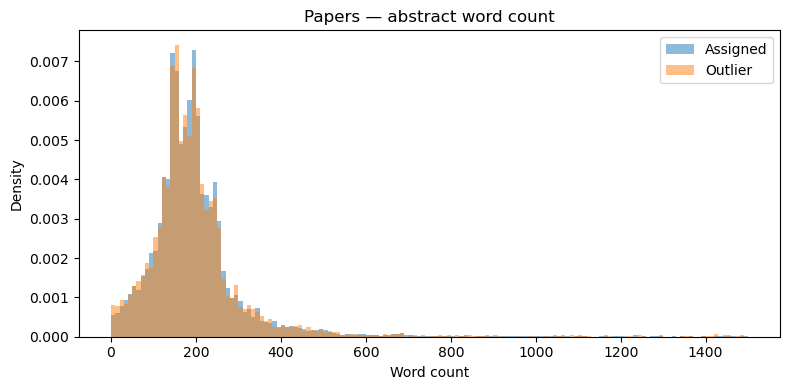

  ≤10 words  →  outliers: 52 (0.8%)  |  assigned: 77 (0.6%)
  ≤20 words  →  outliers: 99 (1.6%)  |  assigned: 150 (1.2%)
  ≤50 words  →  outliers: 285 (4.6%)  |  assigned: 511 (4.0%)

  Teams — abstract word count: no outliers — skipping plot.


In [5]:
plot_text_length(papers, "abstract", "Papers — abstract word count")
print()
plot_text_length(teams, "AB", "Teams — abstract word count")

## 5. Language distribution (papers only)

Non-English papers encoded with an English sentence-transformer may produce
out-of-distribution embeddings that cluster poorly.

In [6]:
lang = language_outlier_table(papers)
if lang is not None:
    display(lang)

topic,assigned,outlier,total,outlier_rate
language,,,,
en,12796,6221,19017,0.327128


## 6. Embedding distance to nearest cluster centroid

For each outlier document we measure the cosine distance to the nearest cluster
centroid. Documents close to a centroid might be recoverable; truly isolated
documents are genuine noise.

── Papers ─────────────────────────────────────────


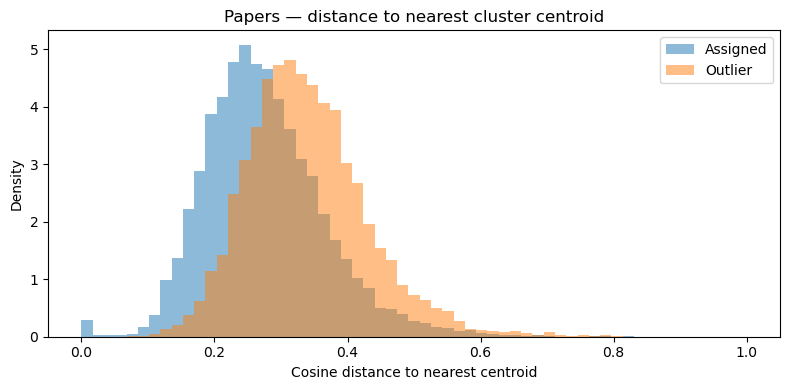

  Papers outlier distance quantiles:
    10%: 0.2341
    25%: 0.2777
    50%: 0.3312
    75%: 0.3908
    90%: 0.4549
  Papers assigned distance quantiles:
    10%: 0.1716
    25%: 0.2137
    50%: 0.2660
    75%: 0.3258
    90%: 0.3894

  Outliers closer than median assigned distance (0.2660): 1,269 / 6,221 (20.4%)

── Teams ──────────────────────────────────────────
  Teams: no outliers — skipping centroid analysis.


In [7]:
print("── Papers ─────────────────────────────────────────")
papers_dists_out, papers_dists_asg = nearest_centroid_analysis(
    papers_emb, papers_topics["topic"].values, "Papers"
)
print()
print("── Teams ──────────────────────────────────────────")
teams_dists_out, teams_dists_asg = nearest_centroid_analysis(
    teams_emb, teams_topics["topic"].values, "Teams"
)

## 7. Citation profile of outliers (papers)

Low-citation outliers may be marginal or off-topic. High-citation outliers are
worth investigating further.

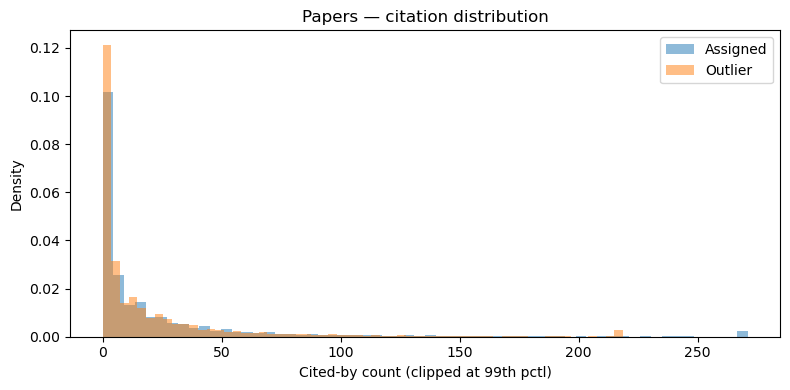

,count,mean,std,min,25%,50%,75%,max
Assigned,12796.0,24.739762,64.161742,0.0,0.0,6.0,24.0,1983.0
Outlier,6221.0,22.593313,70.575449,0.0,0.0,5.0,23.0,2622.0


In [8]:
display(citation_profile(papers))

## 8. Concept overlap (papers)

OpenAlex assigns concept tags to each paper. If outlier papers carry very
different concepts they may be genuinely off-topic.

In [9]:
display(concept_overlap(papers))

,rank_outliers,concept,count_outliers,rank_assigned,count_assigned
0,1,Biology,3354,1.0,6843.0
1,2,Computational biology,2168,2.0,4248.0
2,3,Chemistry,1954,3.0,3889.0
3,4,Computer science,1858,4.0,3427.0
4,5,Synthetic biology,1688,5.0,3156.0
5,6,Gene,1134,6.0,2316.0
6,7,Genetics,990,7.0,1998.0
7,8,Biochemistry,949,9.0,1658.0
8,9,Nanotechnology,894,8.0,1688.0
9,10,Cell biology,774,10.0,1578.0


## 9. Sample outlier documents

A random sample of outlier titles/abstracts helps build intuition about what
kind of documents are being left out.

In [10]:
sample_outlier_docs(papers, "title", "abstract", "publication_year", "PAPERS", k=10, seed=SEED)
sample_outlier_docs(teams, "TI", "AB", "PY", "TEAMS", k=10, seed=SEED)

── 10 random outlier PAPERS ──────────────────────────────────
  [2024]  Simulation and experimental study of a cold atmospheric pressure plasma and comparison of efficiency in boosting recombinant Endoglucanase II production in Pichia pastoris
         Recombinant proteins are essential in various industries, and scientists employ genetic engineering and synthetic biology to enhance the host cell's protein production capacity. Stress response pathwa...

  [2017]  Making it big in the oligos market
         Oligonucleotides come in many different flavors depending on their sequence, length, and purity. Served up in a variety of custom combinations and formats, these nucleic acid oligomers are consumed in...

  [2020]  Recombination of 2Fe-2S Ferredoxins Reveals Differences in the Inheritance of Thermostability and Midpoint Potential
         Recombination can be used in the laboratory to overcome component limitations in synthetic biology by creating enzymes that exhibit distinct activ

In [11]:
# Random sample of outlier teams (table view)
sample = sample_outlier_table(
    teams, ["UT", "PY", "TI", "AB"], k=20, seed=SEED,
    truncate_col="AB", truncate_len=300,
)
if sample is None:
    print("No outlier teams to display.")
else:
    display(sample)

No outlier teams to display.


## Save orphan documents

In [12]:
orphan_papers = save_orphans(
    papers, ["id", "publication_year", "title", "abstract"], "orphans_papers.tsv"
)
orphan_teams = save_orphans(teams, ["UT", "PY", "TI", "AB"], "orphans_teams.tsv")
print(f"Saved {len(orphan_papers):,} orphan papers → orphans_papers.tsv")
print(f"Saved {len(orphan_teams):,} orphan teams  → orphans_teams.tsv")

Saved 6,221 orphan papers → orphans_papers.tsv
Saved 0 orphan teams  → orphans_teams.tsv


## 10. Summary

Collect the key findings into a single table.

In [13]:
summary = pd.DataFrame([
    build_summary(papers, papers_emb, papers_topics["topic"].values, "Papers", "abstract"),
    build_summary(teams, teams_emb, teams_topics["topic"].values, "Teams", "AB"),
]).set_index("dataset")
display(summary)

,total,assigned,outliers,outlier_rate,outliers_≤20_words,near_centroid,far_from_clusters
dataset,,,,,,,
Papers,19017,12796,6221,32.7%,99 (1.6%),"1,269 (20.4%)","4,952 (79.6%)"
Teams,4707,4707,0,0.0%,0,0,0
